In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)

In [4]:
#Desfining state

from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
# defining nodes
def chat_node(state: ChatState):
    # take user query from the state
    messages = state["messages"]
    
    ## send to llm
    response = llm.invoke(messages)
    #response store state
    return {"messages":[response]}
    

In [11]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

#Adding nodes

graph.add_node('chat_node',chat_node)

## Add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

#Compile the graph
chatbot = graph.compile(checkpointer=checkpoint)


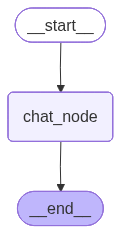

In [12]:
chatbot

In [8]:
initial_state ={"messages":  [HumanMessage(content="Tell me about tarakmehta ka ulta chasma ?")] }

response = chatbot.invoke(initial_state)

In [9]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Tell me about tarakmehta ka ulta chasma ?
================================== Ai Message ==================================

"Taarak Mehta Ka Ooltah Chashmah" (TMKOC) is an incredibly popular and long-running Indian Hindi-language television sitcom. It's one of the most watched and beloved shows in Indian television history.

Here's a breakdown of what it's all about:

1.  **Name:** The full name is "Taarak Mehta Ka Ooltah Chashmah," which translates to "Taarak Mehta's Inverted Spectacles." The "inverted spectacles" signify looking at life's problems from a different, often humorous, perspective.

2.  **Genre:** It's a family-friendly comedy sitcom.

3.  **Channel & Duration:** It airs on **SAB TV (Sony SAB)** and has been running continuously since **July 28, 2008**, making it one of the longest-running daily sitcoms in the world.

4.  **Premise & Setting:**
    *   The show revolves around the residents 

In [14]:
thread_id = "1"

while True:
    user_message = input("Type Here: ").strip()

    if not user_message:
        print("Please enter a message.")
        continue

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break
    
    config = {"configurable": {"thread_id": thread_id}}

    response = chatbot.invoke({
        "messages": [HumanMessage(content=user_message)]},
        config=config
    )

    print("AI:", response["messages"][-1].content)

AI: Hello! How can I help you today?
AI: Nice to meet you, Sahil!

How can I help you today?
AI: Mumbai is located on the **west coast of India**, in the state of **Maharashtra**.

It's situated on the **Arabian Sea**, making it a major port city.
AI: That's great, Sahil! Mumbai is a fantastic city.

Is there anything else you'd like to know or discuss about Mumbai, or anything else at all?
AI: Based on our conversation so far, Sahil, I know two things about you:

1.  Your name is **Sahil**.
2.  You **stay in Mumbai**.

As an AI, I don't have personal memory or access to any information about you beyond what you tell me in our current chat. I don't store personal data or remember past conversations with individuals.
